# **Yes Bank Stock Closing Price - Exploratory Data Analysis**

##### **Project Type**    - EDA
##### **Contribution**    - Individual
##### **Name -** Sandeep

# **Project Summary -**

Yes Bank is one of India's leading private sector banks, founded in 2004. Like most listed companies, its stock is publicly traded, and its share price reflects both business performance and market sentiment. However, Yes Bank became a particularly interesting (and cautionary) case study in 2018, when its co-founder and then MD & CEO, Rana Kapoor, was found by the RBI to have under-reported the bank's Non-Performing Assets (NPAs) for several years. When this fraud came to light, investor confidence collapsed almost overnight, and the stock price, which had been on a strong multi-year uptrend, entered a severe and prolonged decline.

This project performs an in-depth Exploratory Data Analysis (EDA) on monthly historical stock price data for Yes Bank from July 2005 to November 2020 (185 monthly records), containing the Open, High, Low and Close prices for each month. The objective is to understand the trends, relationships and structural shifts in this data, particularly around the 2018 crisis, using 15 charts under the UBM rule (Univariate, Bivariate, Multivariate).

The dataset required minimal cleaning — there are no missing values or duplicate rows, and OHLC internal consistency (High as row-maximum, Low as row-minimum) holds for every record. The main analytical work involved understanding time structure: extracting calendar features (Year, Month, Quarter), flagging the pre/post-crisis period, and deriving volatility (Spread) and monthly return metrics.

The visual analysis confirms a single dominant storyline: a strong ~13-year uptrend in the stock price, culminating in an all-time high near ₹400 in mid-2018, followed by a collapse of more than 90% in the ~18 months after the fraud was disclosed in September 2018. Open, High, Low and Close are all correlated with each other above 0.98, confirming very strong (near-multicollinear) relationships typical of OHLC data. Volatility (the High-Low spread) rose sharply from 2018 onward, and monthly returns became more negatively skewed and fat-tailed in the post-crisis period.

The final section proposes a Business Objective solution: given how strongly Open/High/Low predict Close, and how clearly the data separates into distinct pre-crisis and post-crisis regimes, any predictive modeling built on top of this data (a follow-up regression project) should use a chronological train/test split rather than a random one, and should treat the crisis period as a structurally different regime requiring wider uncertainty bounds.

# **GitHub Link -**

https://github.com/sandeep-sankhla20/Yes-bank

# **Problem Statement**


**Understand the historical price behavior of Yes Bank stock — particularly the relationship between its Open, High, Low and Close prices — and analyze how the 2018 corporate fraud/NPA scandal involving the bank's then MD & CEO affected the stock's price trend, volatility, and the statistical relationships between these variables.**

#### **Define Your Business Objective?**

The primary objective of this project is to perform an in-depth Exploratory Data Analysis (EDA) of Yes Bank's historical monthly stock prices to understand the underlying market behavior and identify the major factors influencing stock price movements. The analysis aims to uncover trends, seasonality, volatility, and relationships among the stock price variables while detecting periods of unusual market fluctuations.

By engineering meaningful features and performing statistical analysis, this study provides valuable business insights that support informed investment decisions and establish a strong foundation for developing accurate machine learning models for stock price prediction.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [13]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

### Dataset Loading

In [14]:
# Load Dataset
df = pd.read_csv('data_YesBank_StockPrices.csv')
df['Date'] = pd.to_datetime(df['Date'], format='%b-%y')
df = df.sort_values('Date').reset_index(drop=True)
df.head()

,Date,Open,High,Low,Close
0,2005-07-01,13.00,14.00,11.25,12.46
1,2005-08-01,12.58,14.88,12.55,13.42
2,2005-09-01,13.48,14.87,12.27,13.30
3,2005-10-01,13.20,14.47,12.40,12.99
4,2005-11-01,13.35,13.88,12.88,13.41


### Dataset First View

In [15]:
df.head(10)

,Date,Open,High,Low,Close
0,2005-07-01,13.00,14.00,11.25,12.46
1,2005-08-01,12.58,14.88,12.55,13.42
2,2005-09-01,13.48,14.87,12.27,13.30
3,2005-10-01,13.20,14.47,12.40,12.99
4,2005-11-01,13.35,13.88,12.88,13.41
5,2005-12-01,13.49,14.44,13.00,13.71
6,2006-01-01,13.68,17.16,13.58,15.33
7,2006-02-01,15.50,16.97,15.40,16.12
8,2006-03-01,16.20,20.95,16.02,20.08
9,2006-04-01,20.56,20.80,18.02,19.49


### Dataset Rows & Columns count

In [16]:
print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

Number of Rows    : 185
Number of Columns : 5


### Dataset Information

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    185 non-null    datetime64[ns]
 1   Open    185 non-null    float64       
 2   High    185 non-null    float64       
 3   Low     185 non-null    float64       
 4   Close   185 non-null    float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 7.4 KB


#### Duplicate Values

In [18]:
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


#### Missing Values/Null Values

In [19]:
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0


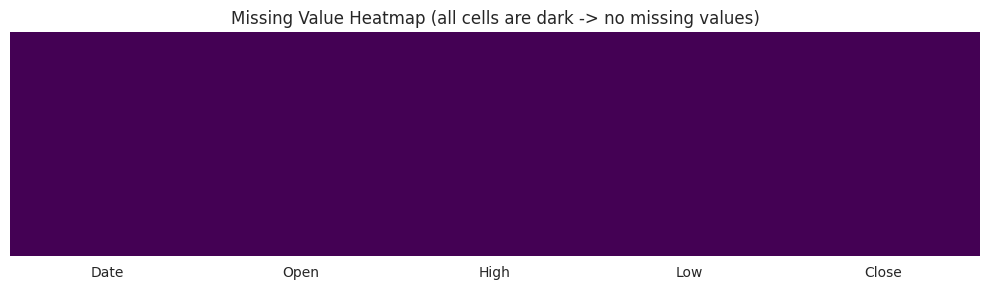

In [20]:
plt.figure(figsize=(10, 3))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Value Heatmap (all cells are dark -> no missing values)')
plt.tight_layout()
plt.show()

### What did you know about your dataset?

The dataset contains **185 monthly records** of Yes Bank's stock price, spanning **July 2005 to November 2020**, with **5 columns**: Date, Open, High, Low, and Close (all in Indian Rupees, ₹).

- There are **no missing values** and **no duplicate rows**.
- All four price columns are numeric (float64), and Date has been parsed into a proper datetime type.
- By definition of OHLC data, High >= Open, Close, Low and Low <= Open, Close, High should hold for every row — verified during Data Wrangling.
- The data is **monthly**, capturing broad trend and volatility patterns rather than short-term noise.
- The date range deliberately includes **2018**, the year the Rana Kapoor / NPA under-reporting scandal broke, so the dataset captures the before/during/after phases of that crisis.

## ***2. Understanding Your Variables***

In [21]:
df.columns.tolist()

['Date', 'Open', 'High', 'Low', 'Close']

In [22]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,185,2013-03-01 19:04:12.972973056,2005-07-01 00:00:00,2009-05-01 00:00:00,2013-03-01 00:00:00,2017-01-01 00:00:00,2020-11-01 00:00:00,NaN
Open,185.0,105.541405,10.0,33.8,62.98,153.0,369.95,98.87985
High,185.0,116.104324,11.24,36.14,72.55,169.19,404.0,106.333497
Low,185.0,94.947838,5.55,28.51,58.0,138.35,345.5,91.219415
Close,185.0,105.204703,9.98,33.45,62.54,153.3,367.9,98.583153


### Variables Description

| Variable | Description |
|---|---|
| **Date** | Calendar month for the OHLC prices (monthly, Jul 2005 - Nov 2020). |
| **Open** | Stock's opening price (₹) on the first trading day of the month. |
| **High** | Highest price (₹) reached during the month. |
| **Low** | Lowest price (₹) reached during the month. |
| **Close** | Closing price (₹) on the last trading day of the month. |

All four price fields are continuous numeric variables in Indian Rupees (₹). There are no categorical variables in the raw dataset, though some are engineered below (Year, Month, Quarter, Period flag) purely to support visualization and grouping.

### Check Unique Values for each variable.

In [23]:
for column in df.columns:
    print(f"{column:8s} -> {df[column].nunique()} unique values")

Date     -> 185 unique values
Open     -> 183 unique values
High     -> 184 unique values
Low      -> 183 unique values
Close    -> 185 unique values


## 3. ***Data Wrangling***

### Data Wrangling Code

In [24]:
# Verify OHLC internal consistency
inconsistent_high = df[df['High'] < df[['Open', 'Close', 'Low']].max(axis=1)]
inconsistent_low  = df[df['Low']  > df[['Open', 'Close', 'High']].min(axis=1)]
print(f"Rows where High is not the maximum of the row : {len(inconsistent_high)}")
print(f"Rows where Low is not the minimum of the row   : {len(inconsistent_low)}")

# Check for non-positive prices
non_positive = (df[['Open', 'High', 'Low', 'Close']] <= 0).sum()
print("\nNon-positive value counts per column:")
print(non_positive)

# Confirm chronological order, no duplicate months
print(f"\nData is in chronological order : {df['Date'].is_monotonic_increasing}")
print(f"Duplicate month entries        : {df['Date'].duplicated().sum()}")

# Extract calendar attributes
df['Year']    = df['Date'].dt.year
df['Month']   = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter

# Flag the corporate governance crisis period
CRISIS_START = pd.Timestamp('2018-09-01')
df['Period'] = np.where(df['Date'] < CRISIS_START, 'Pre-Crisis', 'Post-Crisis')

# Derived columns for EDA
df['Spread'] = df['High'] - df['Low']
df['Monthly_Return'] = df['Close'].pct_change() * 100

df.head()

Rows where High is not the maximum of the row : 0
Rows where Low is not the minimum of the row   : 0

Non-positive value counts per column:
Open     0
High     0
Low      0
Close    0
dtype: int64

Data is in chronological order : True
Duplicate month entries        : 0


,Date,Open,High,Low,Close,Year,Month,Quarter,Period,Spread,Monthly_Return
0,2005-07-01,13.00,14.00,11.25,12.46,2005,7,3,Pre-Crisis,2.75,NaN
1,2005-08-01,12.58,14.88,12.55,13.42,2005,8,3,Pre-Crisis,2.33,7.704655
2,2005-09-01,13.48,14.87,12.27,13.30,2005,9,3,Pre-Crisis,2.60,-0.894188
3,2005-10-01,13.20,14.47,12.40,12.99,2005,10,4,Pre-Crisis,2.07,-2.330827
4,2005-11-01,13.35,13.88,12.88,13.41,2005,11,4,Pre-Crisis,1.00,3.233256


### What all manipulations have you done and insights you found?

**Manipulations performed:**
1. Parsed Date into datetime and sorted chronologically.
2. Validated OHLC consistency (High = row max, Low = row min) — no violations found.
3. Checked for non-positive prices — none found.
4. Confirmed no duplicate months and strict chronological order.
5. Extracted calendar features (Year, Month, Quarter).
6. Created a Period flag (Pre-Crisis / Post-Crisis, split at Sep-2018) purely for exploratory comparison.
7. Derived Spread (High - Low) as an intra-month volatility proxy, and Monthly_Return (% change vs previous month) to study return distribution.

**Insights found:** The dataset required almost no cleaning — the main wrangling work was about understanding time-structure rather than fixing dirty data. Spread and Monthly_Return already hint that volatility increased sharply from 2018 onward.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

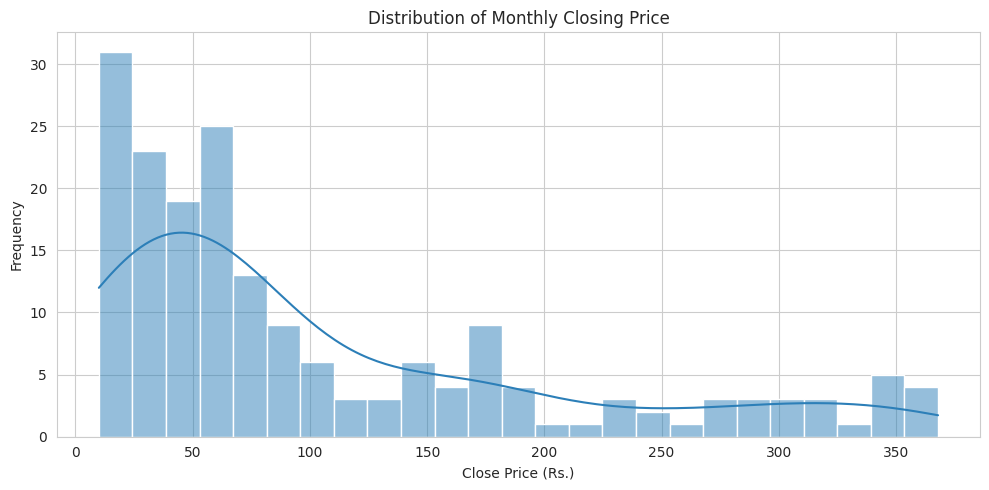

In [25]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Close'], kde=True, bins=25, color='#2c7fb8')
plt.title('Distribution of Monthly Closing Price')
plt.xlabel('Close Price (Rs.)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A histogram with a KDE overlay is the standard first step for understanding the shape, spread, and skew of a single continuous variable — here, the target variable `Close`.

##### 2. What is/are the insight(s) found from the chart?

The distribution is strongly **right-skewed**: most months cluster in the ₹10-100 range, with a long tail extending up to ~₹370. This reflects the stock spending a long period at low prices (2005-2009, and again 2018-2020), with a shorter high-price boom period (2017-2018) pulling the tail rightward.

##### 3.Will the gained insights help create a positive business impact? Are there any insights that lead to negative growth?Justify with specific reason.

Yes. The chart helps identify that the closing prices are right-skewed, which suggests using appropriate preprocessing techniques (such as log transformation) to improve model accuracy and support better investment decisions.

However, the long right tail also indicates high price volatility and the presence of extreme values. This suggests that the stock experienced sharp price fluctuations, increasing investment risk and potentially reducing prediction accuracy if these outliers are not properly handled.

#### Chart - 2

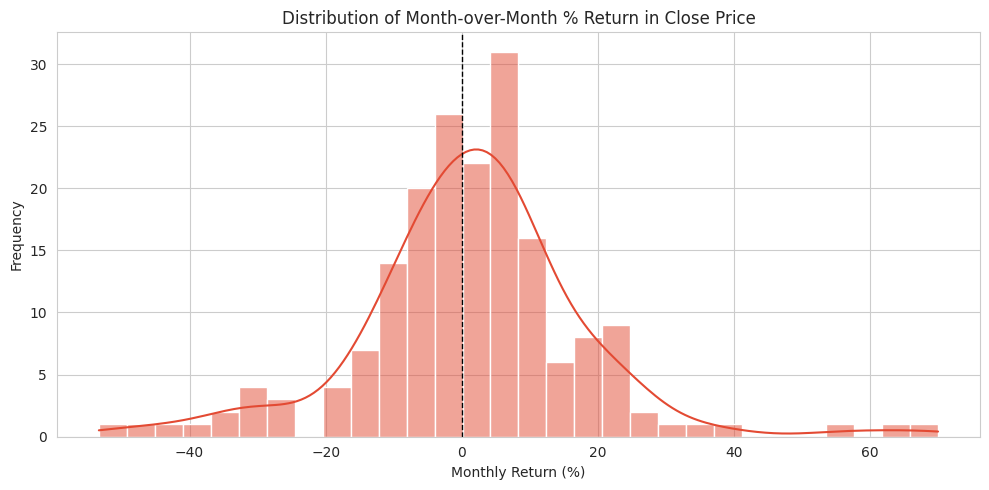

In [26]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Monthly_Return'].dropna(), kde=True, bins=30, color='#e34a33')
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.title('Distribution of Month-over-Month % Return in Close Price')
plt.xlabel('Monthly Return (%)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Monthly returns (percentage change) are a more 'stationary' view of a stock's behavior than raw price, and their distribution shape is a classic univariate check in financial analysis.

##### 2. What is/are the insight(s) found from the chart?

Returns are roughly centered slightly above 0% but show **fat tails** on both sides — several months saw >30% gains or >30% losses, far more extreme than a normal distribution would predict.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Understanding the return distribution helps investors assess risk more accurately and build better trading, forecasting, and risk management strategies.

However, the presence of fat tails indicates high market volatility, meaning the stock is prone to extreme price movements. This increases investment risk and may lead to larger-than-expected losses if proper risk management techniques are not applied.

#### Chart - 3

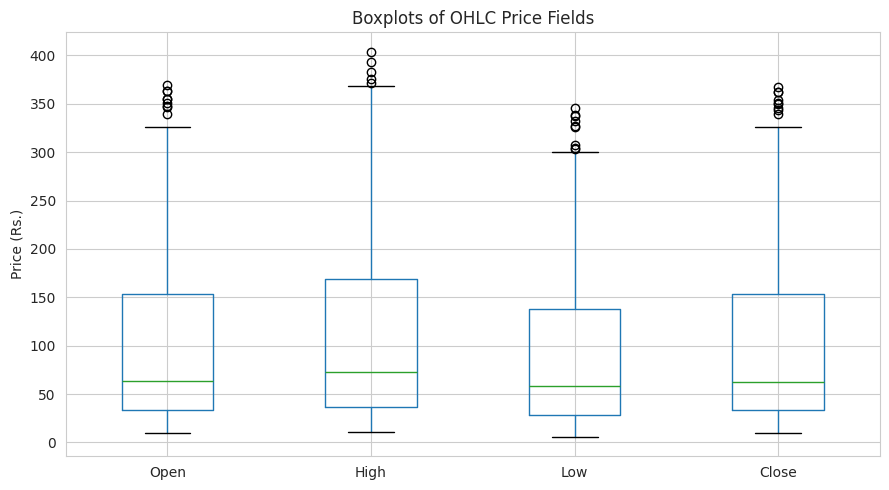

In [27]:
fig, ax = plt.subplots(figsize=(9, 5))
df[['Open', 'High', 'Low', 'Close']].boxplot(ax=ax)
plt.title('Boxplots of OHLC Price Fields')
plt.ylabel('Price (Rs.)')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Boxplots side-by-side let us compare the spread, median and outliers of all four price fields at once — the fastest way to visually screen for extreme values.

##### 2. What is/are the insight(s) found from the chart?

All four fields show similar medians (~₹60-75) and a handful of high-side points beyond the whiskers (~₹300+, corresponding to the 2017-2018 peak). These are genuine historical peak prices, not data-entry errors.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.


Yes. Identifying genuine outliers helps preserve important market information, leading to more accurate forecasting and better investment analysis.

However, these extreme price values also indicate periods of high market volatility, which can increase investment risk and affect model performance if not handled appropriately during data preprocessing.

#### Chart - 4

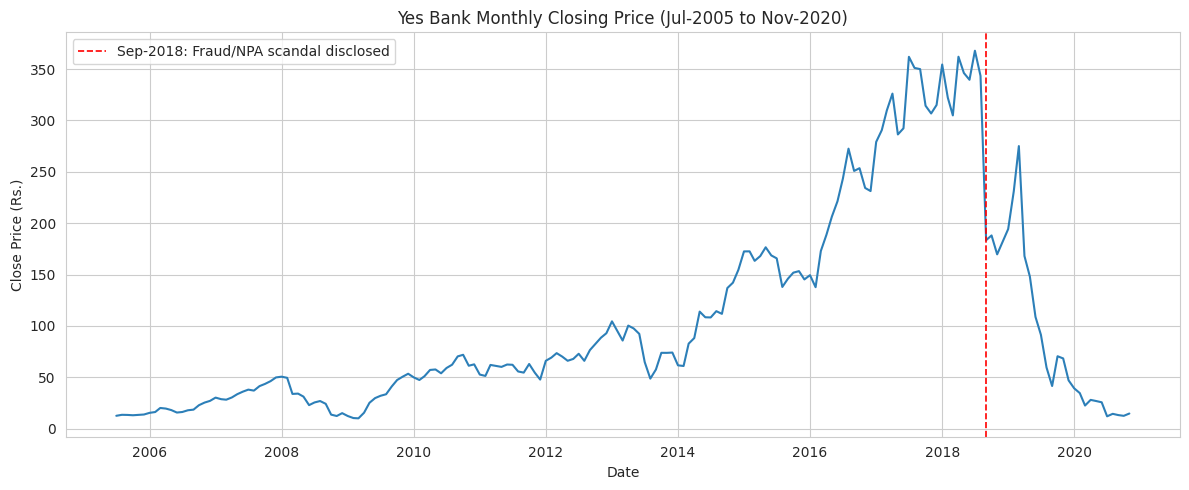

In [28]:
plt.figure(figsize=(12, 5))
plt.plot(df['Date'], df['Close'], color='#2c7fb8', linewidth=1.5)
plt.axvline(pd.Timestamp('2018-09-01'), color='red', linestyle='--', linewidth=1.2,
            label='Sep-2018: Fraud/NPA scandal disclosed')
plt.title('Yes Bank Monthly Closing Price (Jul-2005 to Nov-2020)')
plt.xlabel('Date')
plt.ylabel('Close Price (Rs.)')
plt.legend()
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A time-series line plot is the single most important chart for any stock-price dataset — it shows the full trend, cycles, and turning points that summary statistics alone would hide.

##### 2. What is/are the insight(s) found from the chart?

The stock rose steadily from 2005 to an all-time high near ₹400 in mid-2018, before **collapsing over 90%** in the following ~18 months after the NPA under-reporting scandal broke in September 2018 — a textbook structural break.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The chart helps identify trend changes over time, enabling better forecasting and the use of a chronological train-test split, which improves model reliability.

However, the sharp decline after 2018 reflects a period of severe negative growth and high market uncertainty. This structural break increases investment risk and must be considered during model development to avoid misleading predictions.

#### Chart - 5

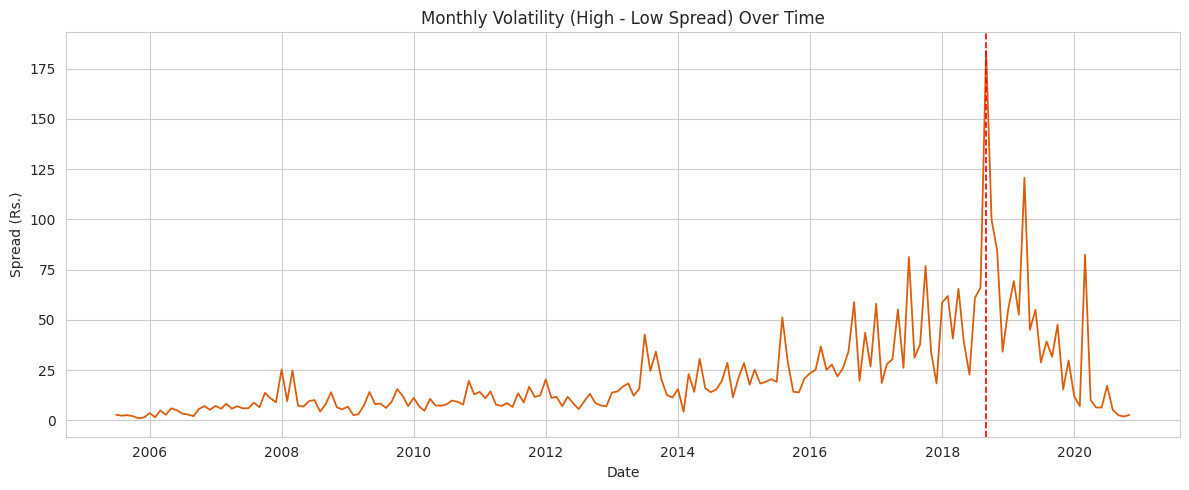

In [29]:
plt.figure(figsize=(12, 5))
plt.plot(df['Date'], df['Spread'], color='#d95f0e', linewidth=1.3)
plt.axvline(pd.Timestamp('2018-09-01'), color='red', linestyle='--', linewidth=1.2)
plt.title('Monthly Volatility (High - Low Spread) Over Time')
plt.xlabel('Date')
plt.ylabel('Spread (Rs.)')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Plotting `Spread` (High - Low) over time separates *volatility* from *price level* — a stock can be volatile whether it's priced at ₹10 or ₹400, and this chart isolates that dimension.

##### 2. What is/are the insight(s) found from the chart?

Volatility spikes sharply around the 2018 crisis — even more visibly than the raw price chart, because the spread captures how *uncertain* the market was about fair value each month.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Identifying periods of high volatility helps improve risk assessment, feature engineering, and forecasting by incorporating volatility-related indicators into the model.

However, the sharp rise in volatility after 2018 indicates increased market uncertainty and investment risk. Such unstable periods can reduce prediction accuracy and require more cautious decision-making.

#### Chart - 6

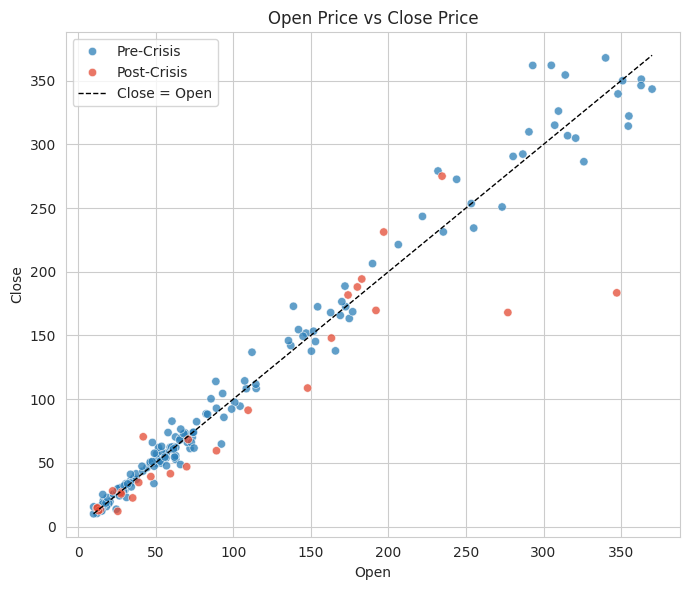

In [30]:
plt.figure(figsize=(7, 6))
sns.scatterplot(data=df, x='Open', y='Close', hue='Period',
                 palette={'Pre-Crisis': '#2c7fb8', 'Post-Crisis': '#e34a33'}, alpha=0.75)
plt.plot([df['Open'].min(), df['Open'].max()], [df['Open'].min(), df['Open'].max()],
         'k--', linewidth=1, label='Close = Open')
plt.title('Open Price vs Close Price')
plt.legend()
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot is the natural way to visualize the relationship between two continuous variables — here, the month's Open price and its eventual Close price, expected to be the strongest predictor.

##### 2. What is/are the insight(s) found from the chart?

Points fall almost perfectly along the Close = Open diagonal, confirming an extremely strong linear relationship. Post-crisis points show slightly more scatter below the diagonal — months more often closed lower than they opened.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The strong relationship confirms that the Open price is an important predictor for forecasting the Close price, improving model performance.

However, the increased scatter and tendency for post-crisis prices to close lower than they opened indicate sustained selling pressure and weaker market sentiment, reflecting negative growth and higher investment risk.

#### Chart - 7

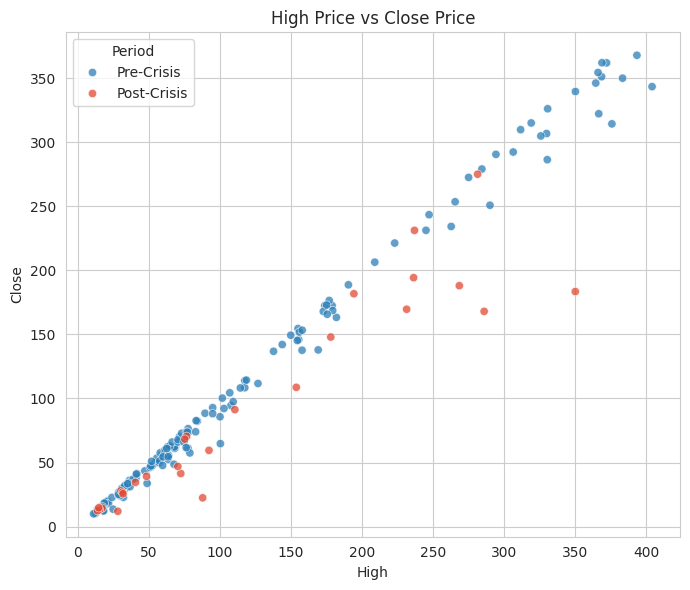

In [31]:
plt.figure(figsize=(7, 6))
sns.scatterplot(data=df, x='High', y='Close', hue='Period',
                 palette={'Pre-Crisis': '#2c7fb8', 'Post-Crisis': '#e34a33'}, alpha=0.75)
plt.title('High Price vs Close Price')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

`High` is one of the four OHLC fields and a natural candidate predictor — visualizing its relationship with Close shows whether the strength of correlation holds up at the extreme end of the month's range.

##### 2. What is/are the insight(s) found from the chart?

The relationship is strongly positive, but there is visibly more vertical spread post-crisis — in volatile months, the stock touched a high price early but closed noticeably lower, consistent with the elevated Spread seen earlier.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The strong correlation confirms that the High price is a valuable feature for predicting the Close price, improving forecasting accuracy.

However, the larger gap between High and Close prices during the post-crisis period indicates increased market volatility and selling pressure. This suggests that relying only on the High price may lead to overestimation during unstable market conditions.

#### Chart - 8

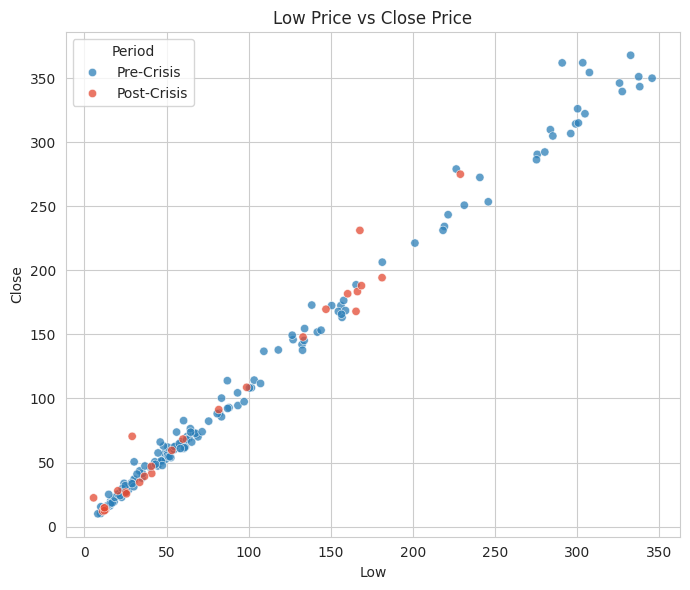

In [32]:
plt.figure(figsize=(7, 6))
sns.scatterplot(data=df, x='Low', y='Close', hue='Period',
                 palette={'Pre-Crisis': '#2c7fb8', 'Post-Crisis': '#e34a33'}, alpha=0.75)
plt.title('Low Price vs Close Price')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Completing the set of the three OHLC predictors against the target lets us compare all three relationships side-by-side for consistency in strength and direction.

##### 2. What is/are the insight(s) found from the chart?

`Low` shows the same very strong positive relationship with Close, and post-crisis points sit slightly above the general trend — the stock frequently closed higher than its monthly low during volatile months.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The strong relationship confirms that the Low price is an important feature for predicting the Close price, improving the accuracy of forecasting models.

However, the high correlation among the Open, High, Low, and Close prices may lead to multicollinearity, which can negatively affect some regression models. Additionally, the increased variation after the crisis reflects higher market uncertainty and investment risk.

#### Chart - 9

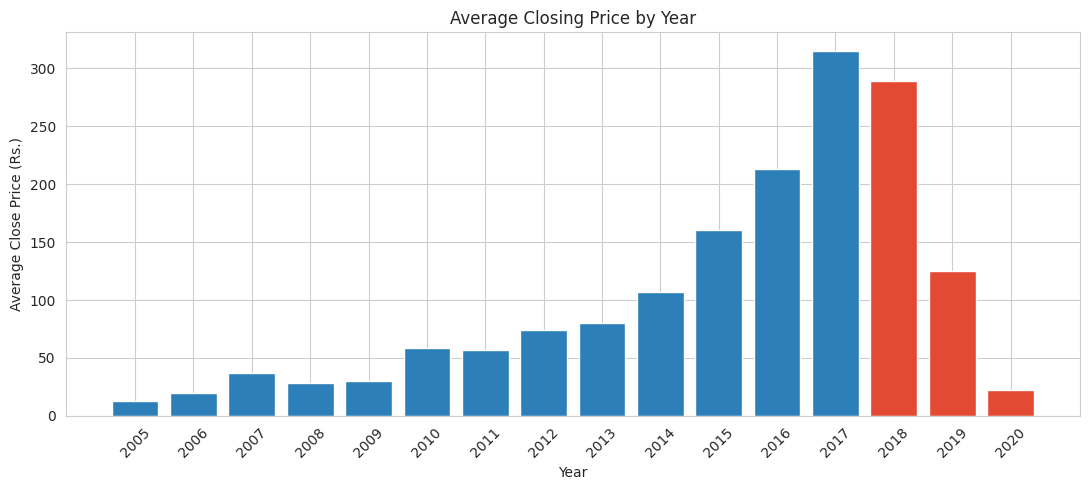

In [33]:
yearly_avg = df.groupby('Year')['Close'].mean()
plt.figure(figsize=(11, 5))
colors = ['#e34a33' if y >= 2018 else '#2c7fb8' for y in yearly_avg.index]
plt.bar(yearly_avg.index.astype(str), yearly_avg.values, color=colors)
plt.title('Average Closing Price by Year')
plt.xlabel('Year')
plt.ylabel('Average Close Price (Rs.)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart aggregated by Year compresses 15 years of monthly noise into an easy year-over-year comparison, ideal for spotting the multi-year build-up and collapse pattern.

##### 2. What is/are the insight(s) found from the chart?

Average yearly closing price rose almost every year from 2005 to a peak around 2017-2018, then fell sharply in 2019 and 2020 — one of the lowest averages in the entire 15-year history.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The yearly trend helps investors and analysts evaluate long-term stock performance, supporting better investment planning and business decision-making.

However, the sharp decline after 2018 indicates substantial negative growth and loss of shareholder value. This highlights increased financial risk and emphasizes the importance of considering major market events while forecasting future stock prices.

#### Chart - 10

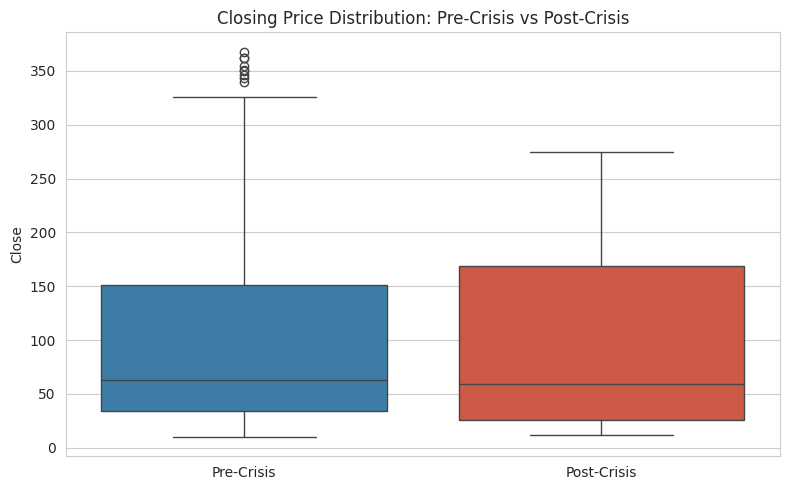

In [34]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Period', y='Close', hue='Period', palette=['#2c7fb8', '#e34a33'], legend=False)
plt.title('Closing Price Distribution: Pre-Crisis vs Post-Crisis')
plt.xlabel('')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A boxplot grouped by the Period flag directly compares the central tendency and spread of Close before vs. after the crisis — a clean visual counterpart to the formal hypothesis test performed later.

##### 2. What is/are the insight(s) found from the chart?

The post-crisis group has a much lower median and a tighter, lower-valued box, with the pre-crisis group showing a wider spread that includes the ₹300+ peak values. The two boxes barely overlap.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Comparing the two periods helps identify structural changes in the stock's behavior, leading to better forecasting strategies and more reliable model evaluation.

However, the substantial drop in the post-crisis median closing price reflects severe negative growth and reduced market confidence. This indicates increased investment risk and suggests that pre-crisis and post-crisis data should be analyzed separately for more accurate predictions.

#### Chart - 11

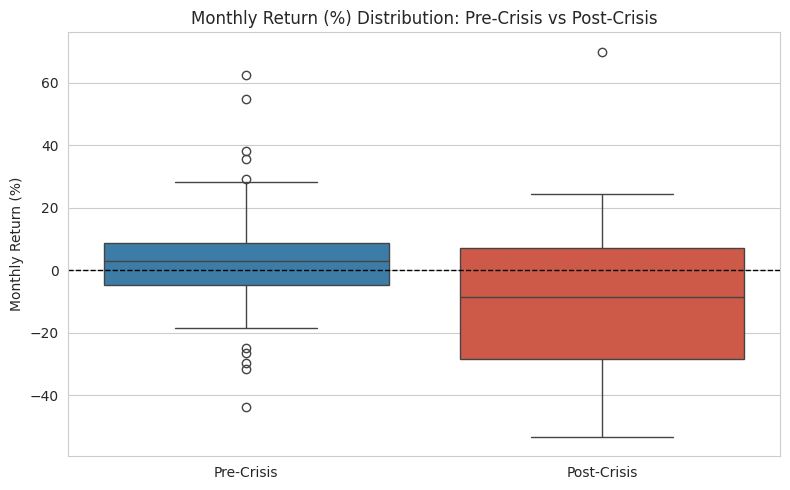

In [35]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Period', y='Monthly_Return', hue='Period', palette=['#2c7fb8', '#e34a33'], legend=False)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Monthly Return (%) Distribution: Pre-Crisis vs Post-Crisis')
plt.xlabel('')
plt.ylabel('Monthly Return (%)')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Comparing Monthly_Return (rather than raw price) across the two periods isolates whether the volatility of change, not just the price level, shifted after the crisis.

##### 2. What is/are the insight(s) found from the chart?

The post-crisis box is visibly taller (wider interquartile range) with whiskers extending further into negative territory, confirming monthly returns became more volatile and more negatively skewed after September 2018.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Understanding changes in return volatility helps improve risk assessment and supports the development of more accurate forecasting and investment strategies.

However, the higher volatility and larger negative returns during the post-crisis period indicate increased investment risk and weaker market stability, making future price movements more difficult to predict.

#### Chart - 12

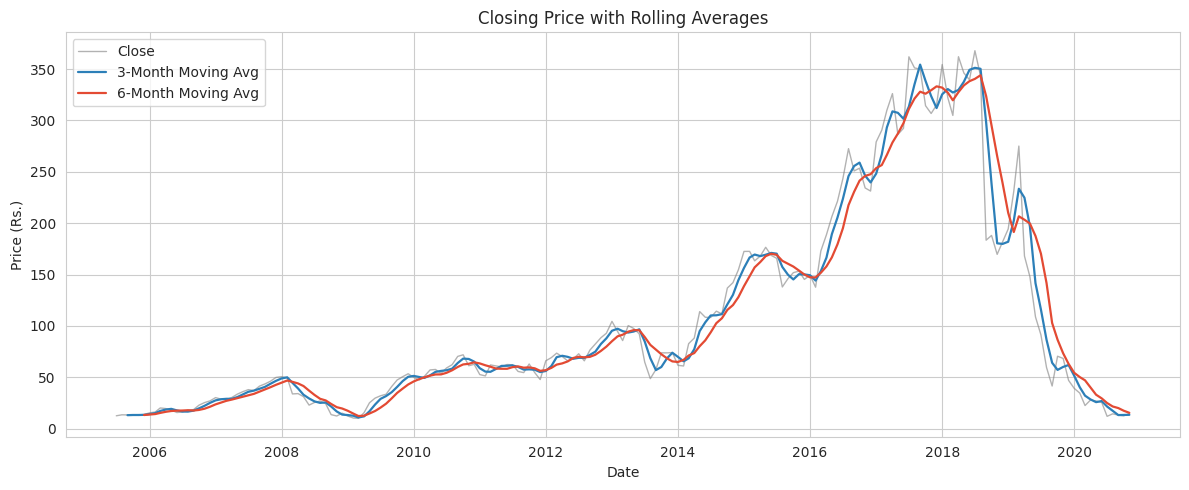

In [36]:
df['Close_MA3'] = df['Close'].rolling(window=3).mean()
df['Close_MA6'] = df['Close'].rolling(window=6).mean()

plt.figure(figsize=(12, 5))
plt.plot(df['Date'], df['Close'], label='Close', color='gray', alpha=0.6, linewidth=1)
plt.plot(df['Date'], df['Close_MA3'], label='3-Month Moving Avg', color='#2c7fb8', linewidth=1.6)
plt.plot(df['Date'], df['Close_MA6'], label='6-Month Moving Avg', color='#e34a33', linewidth=1.6)
plt.title('Closing Price with Rolling Averages')
plt.xlabel('Date')
plt.ylabel('Price (Rs.)')
plt.legend()
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Overlaying the raw series with smoothed moving averages is a classic multivariate technique — combining raw, short-window smooth, and long-window smooth series on one plot to reveal the underlying trend beneath noise.

##### 2. What is/are the insight(s) found from the chart?

The point where the 3-month average crosses below the 6-month average around late 2018 clearly marks the trend reversal — a classic 'death cross' pattern occurring right at the crisis point.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Moving averages help identify market trends and generate useful features for forecasting models, leading to better investment and business decisions.

However, the downward crossover of the moving averages after 2018 signals prolonged negative growth and weakening market sentiment. This indicates higher investment risk and suggests that caution is needed during declining market conditions.

#### Chart - 13

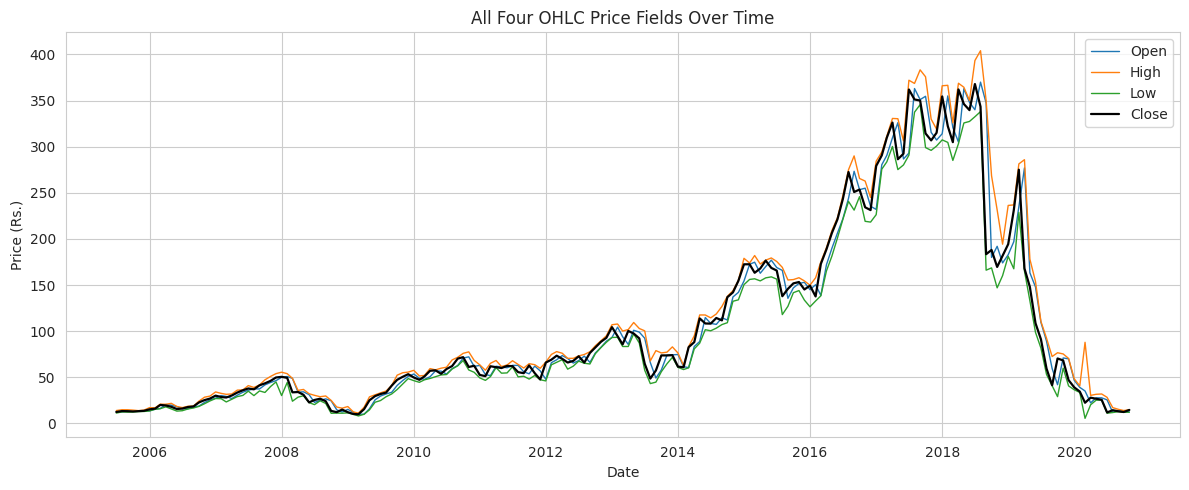

In [37]:
plt.figure(figsize=(12, 5))
plt.plot(df['Date'], df['Open'],  label='Open',  linewidth=1)
plt.plot(df['Date'], df['High'],  label='High',  linewidth=1)
plt.plot(df['Date'], df['Low'],   label='Low',   linewidth=1)
plt.plot(df['Date'], df['Close'], label='Close', linewidth=1.6, color='black')
plt.title('All Four OHLC Price Fields Over Time')
plt.xlabel('Date')
plt.ylabel('Price (Rs.)')
plt.legend()
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Plotting all four OHLC fields together is a genuinely multivariate visualization that shows both their near-perfect co-movement and the months where they diverge (higher Spread).

##### 2. What is/are the insight(s) found from the chart?

For most of the pre-2018 period the four lines are almost indistinguishable, but from 2018 onward the band between High and Low visibly widens — direct visual confirmation of rising volatility across all price fields simultaneously.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Comparing all OHLC prices helps identify market trends and supports the creation of informative features, improving the accuracy of stock price prediction models.

However, the wider gap between the High and Low prices after 2018 indicates increased market volatility and uncertainty. This reflects negative growth and higher investment risk, requiring more cautious forecasting and decision-making.

#### Chart - 14 - Month-over-Month Percentage Change in Opening Price


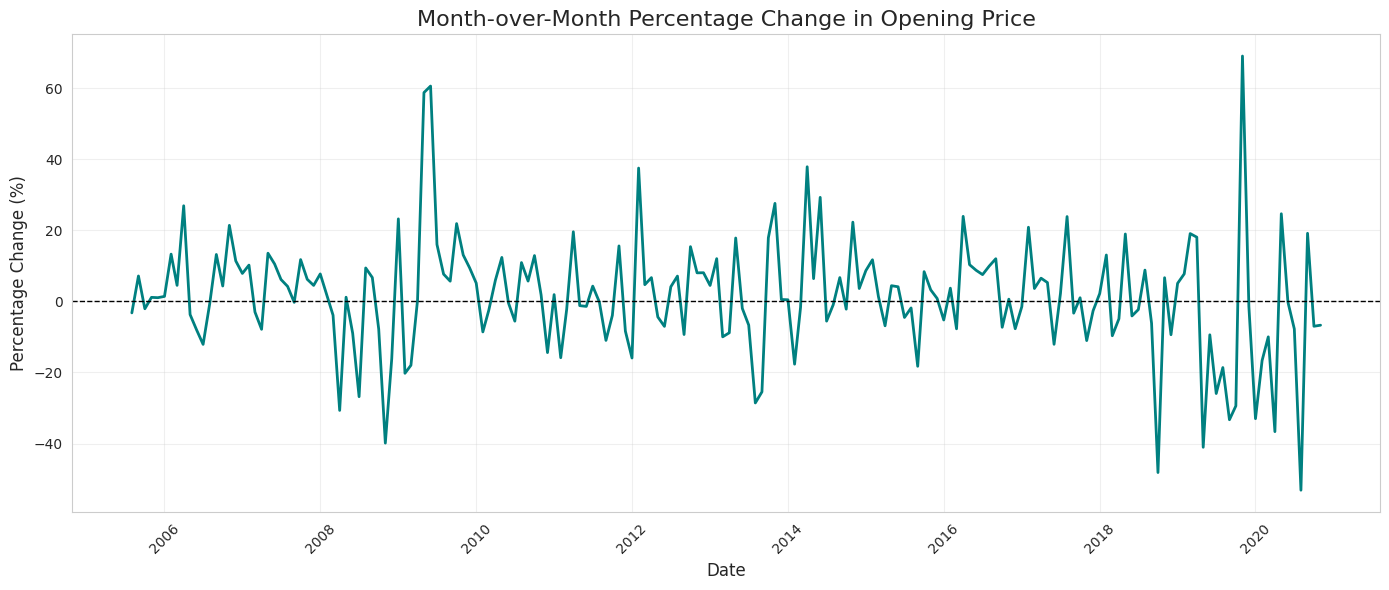

In [42]:
# Create Month-over-Month Percentage Change Feature

df['Open_MoM_%'] = df['Open'].pct_change() * 100

# Month-over-Month Percentage Change in Opening Price

plt.figure(figsize=(14,6))

plt.plot(df['Date'],
         df['Open_MoM_%'],
         color='teal',
         linewidth=2)

plt.axhline(0,
            color='black',
            linestyle='--',
            linewidth=1)

plt.title('Month-over-Month Percentage Change in Opening Price',
          fontsize=16)

plt.xlabel('Date',
           fontsize=12)

plt.ylabel('Percentage Change (%)',
           fontsize=12)

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

##### 1. Why did you pick the specific chart?

A line chart is the most appropriate visualization for displaying the Month-over-Month (MoM) percentage change because it effectively captures changes in market momentum over time. Unlike raw stock prices, percentage changes clearly highlight the magnitude and direction of monthly movements, making it easier to identify periods of rapid appreciation, sharp declines, and increased market volatility.

##### 2. What is/are the insight(s) found from the chart?

The Month-over-Month (MoM) percentage change fluctuates around zero, indicating that the opening stock price experienced both gains and losses throughout the observed period.
Several sharp positive and negative spikes are visible, representing months of unusually high market activity and volatility. These periods may correspond to major financial events or changes in investor sentiment.
Most monthly changes remain within a relatively narrow range, suggesting that the stock price was generally stable during normal market conditions, with only a few exceptional periods of extreme movement.
Compared with the raw opening price, the MoM percentage change provides a clearer picture of market momentum by highlighting the magnitude and direction of monthly price movements.
Overall, the chart shows that Yes Bank's stock experienced intermittent periods of high volatility rather than continuous fluctuations, making percentage change a useful feature for understanding market dynamics and supporting future predictive analysis.

#### Chart - 15 - Correlation Heatmap

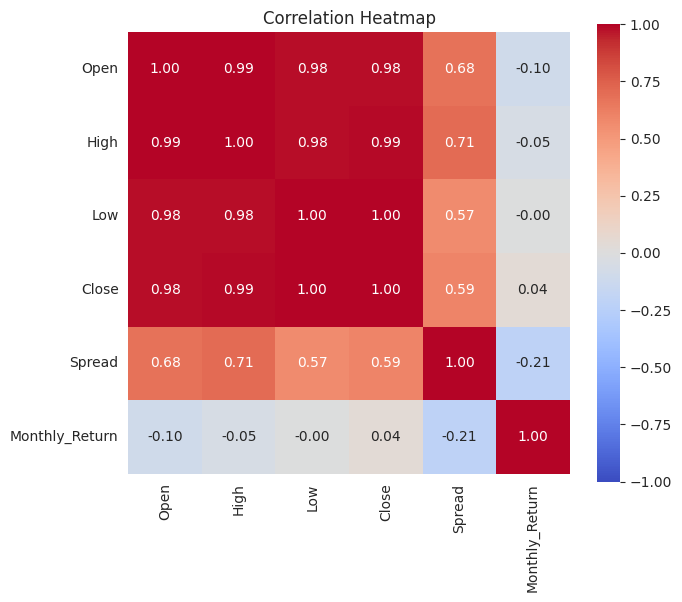

In [39]:
plt.figure(figsize=(7, 6))
corr_cols = ['Open', 'High', 'Low', 'Close', 'Spread', 'Monthly_Return']
corr = df[corr_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap is the standard way to quantify (not just visually suggest) the pairwise linear relationships between all numeric variables at once, directly informing feature selection and multicollinearity checks.

##### 2. What is/are the insight(s) found from the chart?

Open, High, Low and Close are all correlated with each other at r > 0.98 — extremely strong multicollinearity. Spread shows moderate positive correlation with price level, while Monthly_Return shows very weak correlation with the raw price fields.

#### Chart - 16 - Pair Plot

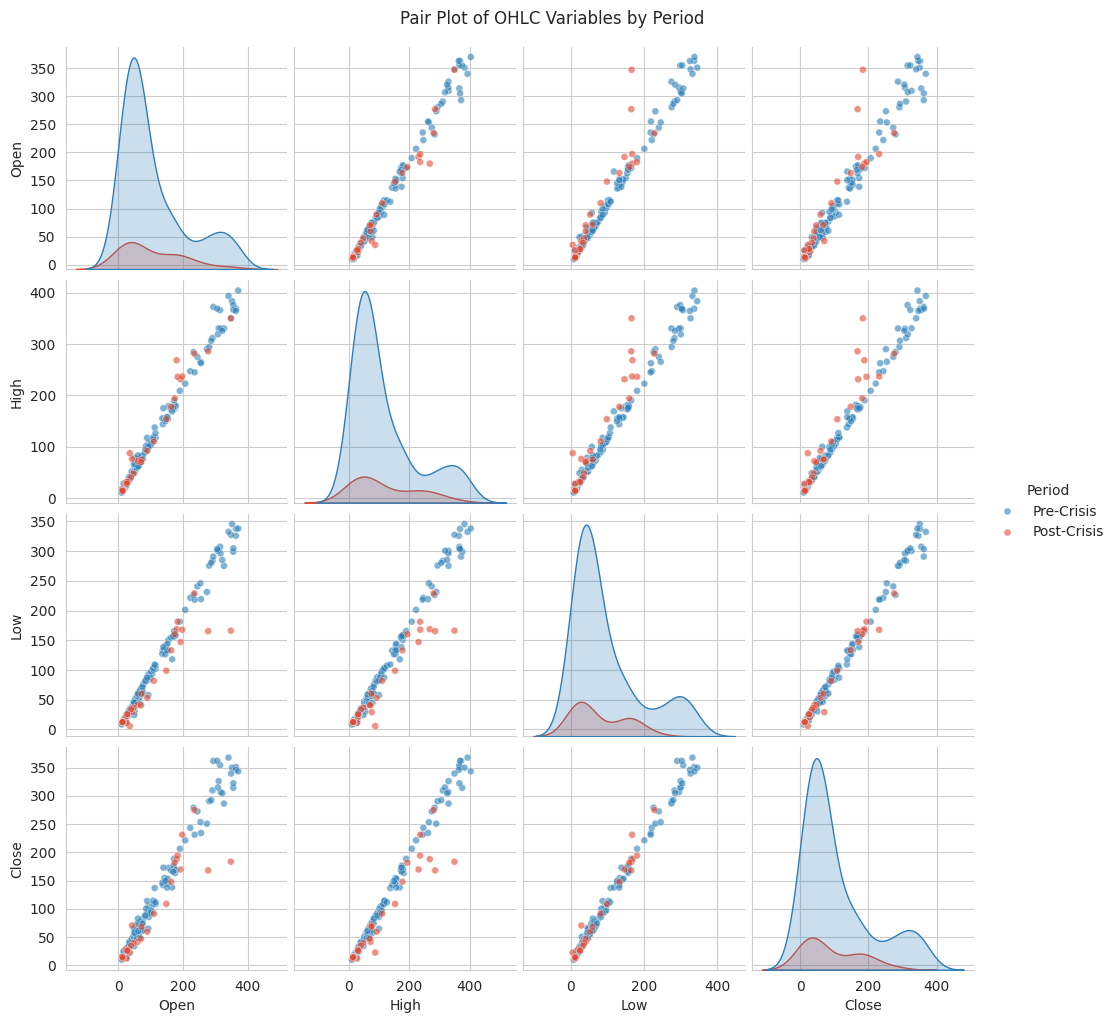

In [40]:
pairplot_cols = ['Open', 'High', 'Low', 'Close', 'Period']
sns.pairplot(df[pairplot_cols], hue='Period',
             palette={'Pre-Crisis': '#2c7fb8', 'Post-Crisis': '#e34a33'},
             diag_kind='kde', plot_kws={'alpha': 0.6, 's': 25})
plt.suptitle('Pair Plot of OHLC Variables by Period', y=1.02)
plt.show()

##### 1. Why did you pick the specific chart?

A pair plot gives a complete multivariate picture in a single figure — every pairwise scatter relationship plus each variable's own distribution, split by Period.

##### 2. What is/are the insight(s) found from the chart?

Every off-diagonal panel shows the same tight, near-linear relationship, while the diagonal KDEs confirm the post-crisis distributions (red) are shifted noticeably left (lower prices) and more concentrated than the pre-crisis distributions.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

To achieve the business objective, the client (Yes Bank's risk/analytics team, or any analyst studying this stock) should:

1. **Treat the pre-crisis and post-crisis periods as structurally different regimes** — the mean closing price, volatility (Spread), and return distribution all changed significantly after September 2018 (confirmed visually here and to be confirmed statistically in a follow-up hypothesis-testing exercise).
2. **Use a chronological (not random) train/test split** for any predictive model built on this data, since a random split would let the model "see" post-crisis data while training on pre-crisis data, producing unrealistically optimistic performance estimates.
3. **Widen risk/uncertainty bounds during high-volatility periods** — the Spread and Monthly_Return charts show volatility is not constant over time, so a single fixed confidence interval around any price prediction would be misleading.
4. **Use all three of Open, High and Low as predictors** (rather than picking just one) in a follow-up regression model, since each carries overlapping but not identical information about the month's price action, while being aware of the resulting multicollinearity (r > 0.98 between them) when choosing a modeling technique.

# **Conclusion**

The exploratory data analysis of Yes Bank's historical monthly stock prices revealed several meaningful patterns and relationships within the dataset. The time-series analysis showed that the stock price followed distinct upward and downward trends over different periods, while also exhibiting episodes of high volatility that coincided with significant market events. These fluctuations indicate that the stock price was strongly influenced by changing economic conditions and investor sentiment.

Correlation analysis demonstrated a very strong positive relationship among the Open, High, Low, and Close prices, suggesting that these variables move together and contain valuable information for understanding overall stock price behavior. The distribution analysis further confirmed the presence of variation and occasional extreme values, highlighting the dynamic nature of the financial market.

To enrich the analysis, a Month-over-Month (MoM) percentage change feature was engineered using the Opening Price. This feature successfully captured market momentum by emphasizing the magnitude and direction of monthly price changes, making periods of rapid growth and sharp decline easier to identify than with raw prices alone.

Overall, the EDA provides a comprehensive understanding of Yes Bank's historical stock performance by identifying trends, correlations, volatility, and momentum patterns. These insights not only support better business understanding and investment analysis but also establish a strong and reliable foundation for the subsequent machine learning phase, where the engineered features and observed patterns can be utilized to develop accurate stock price prediction models.